In [71]:
import os
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import tellurium as te
import roadrunner
from scipy.integrate import solve_ivp
import warnings
from numpy.linalg import eigh

warnings.filterwarnings('ignore')
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

print("TysonSloppyComplexity: sampling complexity vs stiffness")

TysonSloppyComplexity: sampling complexity vs stiffness


In [72]:
# === CONFIGURATION ===
N_SAMPLES = int(1e2)             # Number of parameter samples to analyze
RANDOM_SEED = 123

# Complexity settings (similar to ChenSloppyComplexity)
SIM_TIME = 200.0             # Duration for complexity simulation
SIM_POINTS = 501             # Points in simulation
COARSE_BINS = 50             # Bins for coarse-graining
DIVERGENCE_THRESHOLD = 250   # Threshold for detecting divergence
COARSE_START = 0             # Start time for windowing

# Sloppiness settings (Hessian eigenvalue analysis)
T_FINAL = 100.0              # Duration for sloppiness analysis
N_TIME_POINTS = 1001         # Time points for sensitivity integration
STIFF_THRESHOLD = 1e-3       # Threshold to consider eigenvalue as "stiff" (not sloppy)

# Parameter sampling multipliers (Chico-style approach)
MULTIPLIERS = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Configuration:")
print(f"  N_SAMPLES: {N_SAMPLES}")
print(f"  SIM_TIME: {SIM_TIME}, COARSE_BINS: {COARSE_BINS}")
print(f"  STIFF_THRESHOLD: {STIFF_THRESHOLD:.0e}")
print(f"  MULTIPLIERS: {MULTIPLIERS}")

Configuration:
  N_SAMPLES: 100
  SIM_TIME: 200.0, COARSE_BINS: 50
  STIFF_THRESHOLD: 1e-03
  MULTIPLIERS: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]


In [73]:
# === TYSON MODEL DEFINITION ===
# Base parameters from Tyson Cell Cycle Model (6-state ODE)
p_default = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# Parameters to vary during sampling (exclude k2, k5_minusP which are zero, and CT)
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7",
    "k8_minusP",
    "k9"
]

P = len(param_names)
p_index = {name: i for i, name in enumerate(param_names)}

# Initial conditions
y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])  # [C2, CP, pM, M, Y, YP]

print(f"\nTyson Model: 6 states, {P} kinetic parameters")
print(f"Parameters: {param_names}")


Tyson Model: 6 states, 8 kinetic parameters
Parameters: ['k1_aa_over_CT', 'k3_CT', 'k4', 'k4prime', 'k6', 'k7', 'k8_minusP', 'k9']


In [74]:
# === TYSON MODEL DYNAMICS ===

def F_M(M, p):
    """Activation function for M dephosphorylation"""
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    """Derivative of F_M with respect to M"""
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    """Right-hand side of Tyson model ODEs
    x = [C2, CP, pM, M, Y, YP]
    """
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def jacobian_fx(x, p):
    """Compute df/dx (6x6 Jacobian) analytically at state x"""
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    dF = dF_dM(M, p)
    
    J = np.zeros((6, 6))
    
    # dC2 row
    J[0, 0] = -p["k8_minusP"]
    J[0, 1] = p["k9"]
    J[0, 3] = p["k6"]
    
    # dCP row
    J[1, 0] = p["k8_minusP"]
    J[1, 1] = -k3*Y - p["k9"]
    J[1, 4] = -k3*CP
    
    # dpM row
    J[2, 1] = k3*Y
    J[2, 2] = -F_M(M, p)
    J[2, 3] = -pM * dF + p["k5_minusP"]
    J[2, 4] = k3*CP
    
    # dM row
    J[3, 2] = F_M(M, p)
    J[3, 3] = pM * dF - p["k5_minusP"] - p["k6"]
    
    # dY row
    J[4, 1] = -k3 * Y
    J[4, 4] = -p["k2"] - k3 * CP
    
    # dYP row
    J[5, 3] = p["k6"]
    J[5, 5] = -p["k7"]
    
    return J

def df_dparam(x, p):
    """Compute df/dh for each parameter (returns 6 x P array)
    where h are the parameters in param_names
    """
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    
    dfdh = np.zeros((6, P))
    
    for j, name in enumerate(param_names):
        if name == "k1_aa_over_CT":
            df = np.zeros(6)
            df[4] = p['CT']  # d(dY)/d k1_aa_over_CT = CT
            dfdh[:, j] = df
            
        elif name == "k3_CT":
            coeff = 1.0 / p["CT"]
            df = np.zeros(6)
            df[1] = -coeff * CP * Y     # d(dCP)/d k3_CT
            df[2] =  coeff * CP * Y     # d(dpM)/d k3_CT
            df[4] = -coeff * CP * Y     # d(dY)/d k3_CT
            dfdh[:, j] = df
            
        elif name == "k4":
            df = np.zeros(6)
            dFdk4 = (M / p["CT"])**2
            df[2] = -pM * dFdk4   # dpM
            df[3] =  pM * dFdk4   # dM
            dfdh[:, j] = df
            
        elif name == "k4prime":
            df = np.zeros(6)
            df[2] = -pM
            df[3] =  pM
            dfdh[:, j] = df
            
        elif name == "k6":
            df = np.zeros(6)
            df[0] = M          # d(dC2)/d k6 = M
            df[3] = -M         # d(dM)/d k6 = -M
            df[5] = M          # d(dYP)/d k6 = M
            dfdh[:, j] = df
            
        elif name == "k7":
            df = np.zeros(6)
            df[5] = -YP        # d(dYP)/d k7 = -YP
            dfdh[:, j] = df
            
        elif name == "k8_minusP":
            df = np.zeros(6)
            df[0] = -C2        # d(dC2)/d k8 = -C2
            df[1] =  C2        # d(dCP)/d k8 = +C2
            dfdh[:, j] = df
            
        elif name == "k9":
            df = np.zeros(6)
            df[0] =  CP        # d(dC2)/d k9 = +CP
            df[1] = -CP        # d(dCP)/d k9 = -CP
            dfdh[:, j] = df
    
    return dfdh

print("Tyson model dynamics and Jacobian functions defined")

Tyson model dynamics and Jacobian functions defined


In [75]:
# === COMPLEXITY ANALYSIS (CHICO-STYLE) ===

def sample_parameters(p_base, param_names, multipliers, wildtype=False):
    """Sample parameters by multiplying with random factors"""
    p_new = dict(p_base)
    sampled_factors = {}
    
    if wildtype:
        return p_new, sampled_factors
    
    for name in param_names:
        factor = random.choice(multipliers)
        p_new[name] = p_base[name] * factor
        sampled_factors[name] = factor
    
    return p_new, sampled_factors

def simulate_for_complexity(p, y0, t_span=(0, 100), n_points=501):
    """Simulate the Tyson model for complexity analysis"""
    try:
        sol = solve_ivp(
            lambda t, x: f_rhs(t, x, p),
            t_span,
            y0,
            method='BDF',
            t_eval=np.linspace(t_span[0], t_span[1], n_points),
            rtol=1e-6,
            atol=1e-8
        )
        
        if not sol.success:
            return None, None
        
        return sol.t, sol.y  # time, states (6 x n_points)
    
    except Exception:
        return None, None

def check_divergence(states, threshold=DIVERGENCE_THRESHOLD):
    """Check if any state variable diverges beyond threshold"""
    if threshold is None:
        return False
    return np.any(np.abs(states) > threshold)

def coarse_grain_direct(time, signal, nbins=COARSE_BINS):
    """Coarse-grain signal to nbins points"""
    coarse_time = np.linspace(time[0], time[-1], nbins)
    coarse_signal = np.interp(coarse_time, time, signal)
    return coarse_time, coarse_signal

def up_down_encoding(coarse_time, coarse_signal):
    """Create binary up-down encoding from coarse-grained signal"""
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    encoding = ''.join(['1' if s > 0 else '0' for s in slopes])
    return encoding

def lz76_phrase_count(s: str) -> int:
    """Lempel-Ziv 76 phrase counting algorithm"""
    n = len(s)
    if n == 0:
        return 0
    i = 0
    c = 1
    k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i+k-1]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x: str) -> float:
    """Lempel-Ziv complexity calculation"""
    n = len(x)
    if n == 0:
        return 0.0
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

def compute_complexity(p, y0, observable_idx=3):
    """
    Compute complexity of a Tyson model trajectory
    
    Parameters:
    - p: parameter dictionary
    - y0: initial conditions
    - observable_idx: which state variable to use (default 3 = M)
    
    Returns: complexity (float) or None if simulation fails
    """
    t, states = simulate_for_complexity(p, y0, (0, SIM_TIME), SIM_POINTS)
    
    if t is None or states is None:
        return None
    
    # Check divergence
    if check_divergence(states, DIVERGENCE_THRESHOLD):
        return "divergent"
    
    # Extract observable (M by default, similar to CLB2 in Chen)
    signal = states[observable_idx, :]
    
    # Coarse-grain
    coarse_time, coarse_signal = coarse_grain_direct(t, signal, COARSE_BINS)
    
    # Encode
    encoding = up_down_encoding(coarse_time, coarse_signal)
    
    # Compute complexity
    complexity = CLZ(encoding)
    
    return complexity

print("Complexity analysis functions defined (CLZ on M dynamics)")

Complexity analysis functions defined (CLZ on M dynamics)


In [76]:
# === SLOPPINESS ANALYSIS (HESSIAN COMPUTATION) ===

def augmented_rhs(t, z, p, param_names):
    """Augmented system for sensitivity analysis
    z contains [x(6), S_flat(6*P)] where S_j = h_j * dx/dh_j (log-sensitivities)
    """
    x = z[:6]
    S_flat = z[6:]
    S = S_flat.reshape((6, P), order='F')  # columns are parameters
    
    # Base dynamics
    xdot = f_rhs(t, x, p)
    
    # Jacobians
    A = jacobian_fx(x, p)            # 6x6: df/dx
    df_dh = df_dparam(x, p)         # 6xP: df/dh
    
    # Convert df/dh to df/dlogh: df/dlogh = h * df/dh
    df_dlogh = np.zeros_like(df_dh)
    for j, name in enumerate(param_names):
        hj = p[name]
        df_dlogh[:, j] = hj * df_dh[:, j]
    
    # Sensitivity ODEs: dS_j/dt = A * S_j + df/dlogh_j
    Sdot = A.dot(S) + df_dlogh
    
    return np.concatenate([xdot, Sdot.ravel(order='F')])

def compute_hessian(p, param_names, y0, t_final=T_FINAL, n_points=N_TIME_POINTS):
    """
    Compute Hessian (Fisher Information Matrix) via sensitivity integration
    
    Returns: H (P x P matrix) or None if simulation fails
    """
    # Initial sensitivities (if x0 independent of params)
    S0 = np.zeros((6, P))
    z0 = np.concatenate([y0, S0.ravel(order='F')])
    
    t_eval = np.linspace(0, t_final, n_points)
    
    try:
        sol_aug = solve_ivp(
            lambda t, z: augmented_rhs(t, z, p, param_names),
            (0, t_final),
            z0,
            method='BDF',
            t_eval=t_eval,
            rtol=1e-6,
            atol=1e-8
        )
        
        if not sol_aug.success:
            return None
        
        t = sol_aug.t
        X = sol_aug.y[:6, :]                       # 6 x m
        S_flat = sol_aug.y[6:, :]                  # (6*P) x m
        m = t.size
        
        # Reshape sensitivities: S_time[:, :, i] is 6 x P at time i
        S_time = np.zeros((6, P, m))
        for i in range(m):
            S_time[:, :, i] = S_flat[:, i].reshape((6, P), order='F')
        
        # Output sensitivities (identity observation function)
        J_time = S_time.copy()
        
        # Weighting matrix (equal weights for all observables)
        Ns = 6
        Nc = 1
        Tc = t_final
        sigma = 1.0
        W_diag = np.ones(Ns) * (1.0 / (Nc * Ns * Tc * sigma**2))
        W = np.diag(W_diag)
        
        # Quadrature weights (trapezoid)
        dt = np.diff(t)
        q = np.zeros(m)
        q[0] = dt[0] / 2.0
        q[-1] = dt[-1] / 2.0
        q[1:-1] = 0.5 * (dt[:-1] + dt[1:])
        
        # Accumulate Hessian: H = integral(J^T W J dt)
        H = np.zeros((P, P))
        for i in range(m):
            J_i = J_time[:, :, i]        # (6 x P)
            A_i = J_i.T.dot(W).dot(J_i)  # P x P
            H += q[i] * A_i
        
        return H
    
    except Exception:
        return None

def analyze_hessian(H, stiff_threshold=STIFF_THRESHOLD):
    """
    Analyze Hessian eigenspectrum
    
    Returns: eigenvalues (descending), eigenvectors, stiff_count
    """
    if H is None:
        return None, None, 0
    
    eigvals, eigvecs = eigh(H)
    eigvals = eigvals[::-1]      # descending
    eigvecs = eigvecs[:, ::-1]
    
    # Count stiff (non-sloppy) eigenvalues
    stiff_count = np.sum(eigvals > stiff_threshold)
    
    return eigvals, eigvecs, stiff_count

print("Sloppiness analysis functions defined (full Hessian via sensitivity ODEs)")

Sloppiness analysis functions defined (full Hessian via sensitivity ODEs)


In [77]:
# === RUN SAMPLING: COMPLEXITY vs SLOPPINESS ===

results = []
failed_complexity = 0
failed_sloppiness = 0
error_summary = {}

# Timing analysis
timing_complexity = []
timing_hessian = []

start_time = time.time()

print(f"\nStarting sampling: {N_SAMPLES} samples + wildtype")
print("="*70)

# --- Wildtype analysis first ---
print("\n[WILDTYPE]")
p_wt = dict(p_default)

# Complexity
complexity_wt = compute_complexity(p_wt, y0, observable_idx=3)
if complexity_wt is None or isinstance(complexity_wt, str):
    print(f"  Complexity: FAILED ({complexity_wt})")
else:
    print(f"  Complexity: {complexity_wt:.3f}")
    
    # Sloppiness
    H_wt = compute_hessian(p_wt, param_names, y0)
    if H_wt is None:
        print(f"  Sloppiness: FAILED")
    else:
        eigvals_wt, eigvecs_wt, stiff_count_wt = analyze_hessian(H_wt)
        print(f"  Stiff count (λ > {STIFF_THRESHOLD:.0e}): {stiff_count_wt}/{P}")
        print(f"  Eigenvalue range: [{eigvals_wt[-1]:.2e}, {eigvals_wt[0]:.2e}]")
        
        results.append({
            'label': 'Wildtype',
            'complexity': complexity_wt,
            'stiff_count': stiff_count_wt,
            'eigenvalues': eigvals_wt,
            'params': p_wt
        })

# --- Random samples ---
for i in range(N_SAMPLES):
    # Sample parameters
    p_sample, factors = sample_parameters(p_default, param_names, MULTIPLIERS, wildtype=False)
    
    # Complexity (with timing)
    t_start_cmplx = time.time()
    complexity = compute_complexity(p_sample, y0, observable_idx=3)
    t_cmplx = time.time() - t_start_cmplx
    
    if complexity is None or isinstance(complexity, str):
        failed_complexity += 1
        error_summary['complexity_failed'] = error_summary.get('complexity_failed', 0) + 1
        continue
    
    timing_complexity.append(t_cmplx)
    
    # Sloppiness (with timing)
    t_start_hess = time.time()
    H = compute_hessian(p_sample, param_names, y0)
    t_hess = time.time() - t_start_hess
    
    if H is None:
        failed_sloppiness += 1
        error_summary['sloppiness_failed'] = error_summary.get('sloppiness_failed', 0) + 1
        continue
    
    timing_hessian.append(t_hess)
    
    eigvals, eigvecs, stiff_count = analyze_hessian(H)
    
    results.append({
        'label': f"Sample {i+1}",
        'complexity': complexity,
        'stiff_count': stiff_count,
        'eigenvalues': eigvals,
        'params': p_sample
    })
    
    # Progress update with timer and ETA
    if (i + 1) % max(1, N_SAMPLES // 10) == 0:
        elapsed = time.time() - start_time
        valid = len(results)
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        eta = (N_SAMPLES - (i + 1)) / rate if rate > 0 else 0
        print(f"Progress: {i+1}/{N_SAMPLES} ({100*(i+1)/N_SAMPLES:.1f}%) | "
              f"valid={valid} | failed_cmplx={failed_complexity} | failed_slop={failed_sloppiness} | "
              f"elapsed={elapsed:.1f}s | rate={rate:.2f} samples/s | ETA={eta:.1f}s")

elapsed_total = time.time() - start_time
print(f"\n{'='*70}")
print(f"COMPLETE: {len(results)} valid samples in {elapsed_total:.1f}s")
print(f"Failed - complexity: {failed_complexity}, sloppiness: {failed_sloppiness}")
print(f"{'='*70}")


Starting sampling: 100 samples + wildtype

[WILDTYPE]
  Complexity: 36.496
  Stiff count (λ > 1e-03): 3/8
  Eigenvalue range: [3.40e-09, 8.19e+00]
Progress: 10/100 (10.0%) | valid=11 | failed_cmplx=0 | failed_slop=0 | elapsed=3.9s | rate=2.58 samples/s | ETA=34.8s
Progress: 20/100 (20.0%) | valid=21 | failed_cmplx=0 | failed_slop=0 | elapsed=8.9s | rate=2.26 samples/s | ETA=35.5s
Progress: 30/100 (30.0%) | valid=31 | failed_cmplx=0 | failed_slop=0 | elapsed=12.7s | rate=2.36 samples/s | ETA=29.7s
Progress: 40/100 (40.0%) | valid=41 | failed_cmplx=0 | failed_slop=0 | elapsed=16.5s | rate=2.42 samples/s | ETA=24.8s
Progress: 50/100 (50.0%) | valid=51 | failed_cmplx=0 | failed_slop=0 | elapsed=20.0s | rate=2.50 samples/s | ETA=20.0s
Progress: 60/100 (60.0%) | valid=61 | failed_cmplx=0 | failed_slop=0 | elapsed=24.6s | rate=2.44 samples/s | ETA=16.4s
Progress: 70/100 (70.0%) | valid=71 | failed_cmplx=0 | failed_slop=0 | elapsed=29.3s | rate=2.39 samples/s | ETA=12.5s
Progress: 80/100 (80.

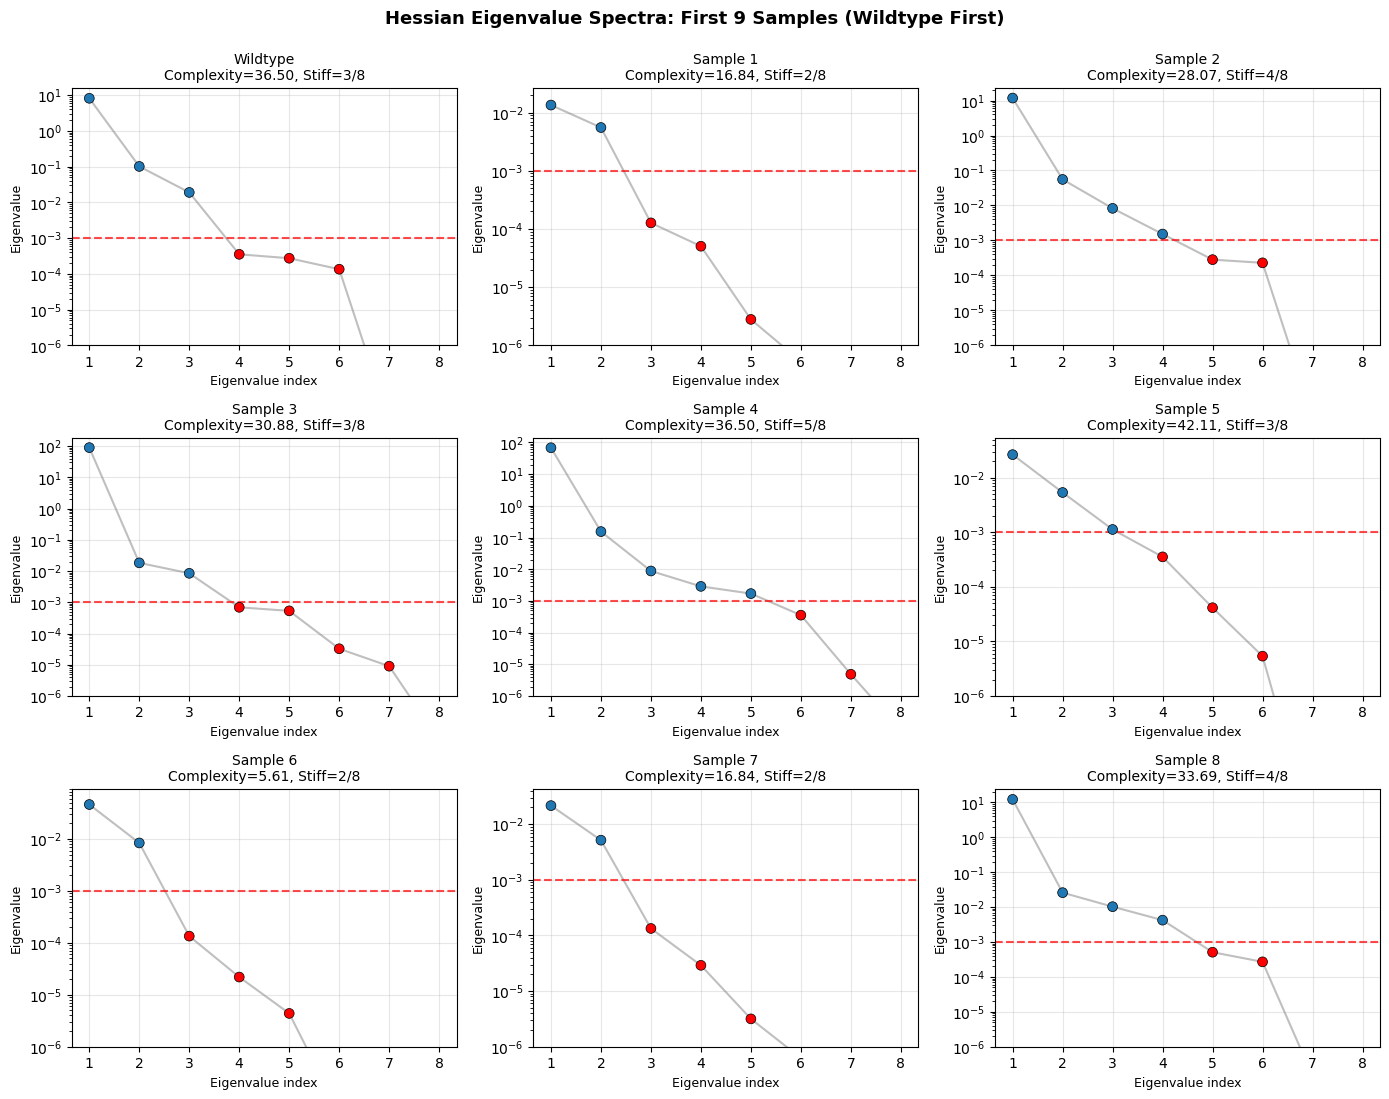

In [78]:
# === VISUALIZATION: EIGENVALUE SPECTRA (FIRST 9 SAMPLES) ===

if len(results) == 0:
    print("No valid results to plot.")
else:
    n_show = min(9, len(results))
    fig, axes = plt.subplots(3, 3, figsize=(14, 11))
    axes = axes.flatten()
    
    for idx in range(n_show):
        entry = results[idx]
        eigenvals = np.asarray(entry['eigenvalues'])
        ax = axes[idx]
        
        x = np.arange(1, len(eigenvals) + 1)
        
        # Color by sloppy/stiff
        colors = ['red' if ev < STIFF_THRESHOLD else 'C0' for ev in eigenvals]
        
        ax.semilogy(x, eigenvals, 'o-', markersize=5, linewidth=1.5, color='gray', alpha=0.5)
        ax.scatter(x, eigenvals, c=colors, s=50, zorder=3, edgecolors='black', linewidths=0.5)
        
        # Threshold line
        ax.axhline(STIFF_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        
        ax.set_title(f"{entry.get('label', f'Sample {idx+1}')}\n"
                     f"Complexity={entry['complexity']:.2f}, Stiff={entry['stiff_count']}/{P}",
                     fontsize=10)
        ax.set_xlabel('Eigenvalue index', fontsize=9)
        ax.set_ylabel('Eigenvalue', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([1e-6, max(eigenvals) * 2])
    
    # Hide unused subplots
    for j in range(n_show, 9):
        axes[j].axis('off')
    
    plt.suptitle('Hessian Eigenvalue Spectra: First 9 Samples (Wildtype First)', 
                 y=0.995, fontsize=13, weight='bold')
    plt.tight_layout()
    plt.show()

In [79]:
# === VISUALIZATION: COMPLEXITY vs STIFFNESS SCATTER ===

if len(results) == 0:
    print("No valid results to plot.")
else:
    complexities = np.array([r['complexity'] for r in results])
    stiff_counts = np.array([r['stiff_count'] for r in results])
    
    # Compute average stiff eigenvalue for each result
    avg_stiff_eigenvals = []
    for r in results:
        eigvals = r['eigenvalues']
        stiff_eigvals = eigvals[eigvals > STIFF_THRESHOLD]
        if len(stiff_eigvals) > 0:
            avg_stiff_eigenvals.append(np.mean(stiff_eigvals))
        else:
            avg_stiff_eigenvals.append(0.0)
    avg_stiff_eigenvals = np.array(avg_stiff_eigenvals)
    
    # Separate wildtype from samples
    is_wt = np.array([r['label'] == 'Wildtype' for r in results])
    
    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT: Stiff count
    ax1.scatter(complexities[~is_wt], stiff_counts[~is_wt], 
                alpha=0.6, s=60, c='steelblue', edgecolors='black', linewidths=0.5,
                label='Random samples')
    if np.any(is_wt):
        ax1.scatter(complexities[is_wt], stiff_counts[is_wt], 
                    alpha=1.0, s=200, c='red', marker='*', edgecolors='black', linewidths=1.5,
                    label='Wildtype', zorder=5)
    ax1.set_xlabel('Complexity (CLZ on M dynamics)', fontsize=12)
    ax1.set_ylabel(f'Stiff eigenvalue count (λ > {STIFF_THRESHOLD:.0e})', fontsize=12)
    ax1.set_title('Complexity vs Stiff Count', fontsize=13, weight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # RIGHT: Average stiff eigenvalue
    ax2.scatter(complexities[~is_wt], avg_stiff_eigenvals[~is_wt], 
                alpha=0.6, s=60, c='darkorange', edgecolors='black', linewidths=0.5,
                label='Random samples')

    if np.any(is_wt):        print(f"  Pearson correlation: {corr:.3f}")

        ax2.scatter(complexities[is_wt], avg_stiff_eigenvals[is_wt],         corr = np.corrcoef(complexities, stiff_counts)[0, 1]

                    alpha=1.0, s=200, c='red', marker='*', edgecolors='black', linewidths=1.5,    if len(complexities) > 2:

                    label='Wildtype', zorder=5)    # Correlation

    ax2.set_xlabel('Complexity (CLZ on M dynamics)', fontsize=12)    

    ax2.set_ylabel(f'Average stiff eigenvalue (λ > {STIFF_THRESHOLD:.0e})', fontsize=12)    print(f"  Mean stiff count: {stiff_counts.mean():.2f} ± {stiff_counts.std():.2f}")

    ax2.set_title('Complexity vs Avg Stiff Eigenvalue', fontsize=13, weight='bold')    print(f"  Mean complexity: {complexities.mean():.2f} ± {complexities.std():.2f}")

    ax2.legend(fontsize=11)    print(f"  Stiff count range: [{stiff_counts.min()}, {stiff_counts.max()}]")

    ax2.grid(True, alpha=0.3)    print(f"  Complexity range: [{complexities.min():.2f}, {complexities.max():.2f}]")

        print("\nStatistics:")

    plt.suptitle('Complexity vs Sloppiness: Tyson Cell Cycle Model',     # Print statistics

                 y=1.02, fontsize=14, weight='bold')    

    plt.tight_layout()    plt.show()

IndentationError: unexpected indent (3324573525.py, line 47)

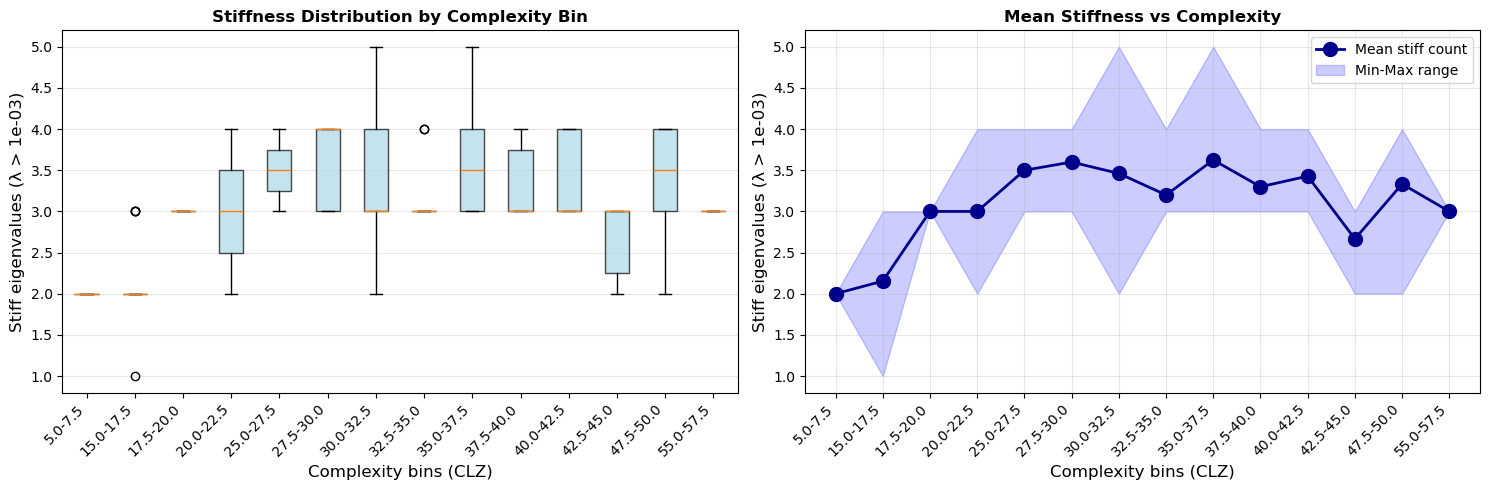


Binned statistics:
  5.0-7.5: mean=2.00, std=0.00, median=2.0, n=8
  15.0-17.5: mean=2.15, std=0.53, median=2.0, n=13
  17.5-20.0: mean=3.00, std=0.00, median=3.0, n=1
  20.0-22.5: mean=3.00, std=0.82, median=3.0, n=3
  25.0-27.5: mean=3.50, std=0.50, median=3.5, n=2
  27.5-30.0: mean=3.60, std=0.49, median=4.0, n=5
  30.0-32.5: mean=3.46, std=0.84, median=3.0, n=13
  32.5-35.0: mean=3.20, std=0.40, median=3.0, n=10
  35.0-37.5: mean=3.62, std=0.70, median=3.5, n=16
  37.5-40.0: mean=3.30, std=0.46, median=3.0, n=10
  40.0-42.5: mean=3.43, std=0.49, median=3.0, n=7
  42.5-45.0: mean=2.67, std=0.47, median=3.0, n=6
  47.5-50.0: mean=3.33, std=0.75, median=3.5, n=6
  55.0-57.5: mean=3.00, std=0.00, median=3.0, n=1


In [ ]:
# === VISUALIZATION: BINNED ANALYSIS ===

if len(results) < 5:
    print("Not enough samples for binned analysis (need at least 5).")
else:
    complexities = np.array([r['complexity'] for r in results])
    stiff_counts = np.array([r['stiff_count'] for r in results])
    
    # Create bins
    c_min, c_max = complexities.min(), complexities.max()
    bin_width = 2.5
    bin_edges = np.arange(np.floor(c_min), np.ceil(c_max) + bin_width, bin_width)
    
    # If too few bins, adjust
    if len(bin_edges) < 3:
        bin_edges = np.linspace(c_min, c_max, 5)
    
    bin_labels = [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(len(bin_edges) - 1)]
    bin_indices = np.digitize(complexities, bin_edges) - 1
    
    binned_counts = []
    binned_labels = []
    bin_means = []
    
    for b in range(len(bin_labels)):
        mask = bin_indices == b
        if np.any(mask):
            binned_counts.append(stiff_counts[mask])
            binned_labels.append(bin_labels[b])
            bin_means.append(np.mean(stiff_counts[mask]))
    
    if len(binned_counts) == 0:
        print("No samples fell into any bin.")
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Boxplot
        bp = ax1.boxplot(binned_counts, labels=binned_labels, 
                         patch_artist=True, showfliers=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        ax1.set_xticklabels(binned_labels, rotation=45, ha='right')
        ax1.set_xlabel('Complexity bins (CLZ)', fontsize=12)
        ax1.set_ylabel(f'Stiff eigenvalues (λ > {STIFF_THRESHOLD:.0e})', fontsize=12)
        ax1.set_title('Stiffness Distribution by Complexity Bin', fontsize=12, weight='bold')
        ax1.grid(True, axis='y', alpha=0.3)
        
        # Trend line
        ax2.plot(range(len(bin_means)), bin_means, 'o-', markersize=10, 
                linewidth=2, color='darkblue', label='Mean stiff count')
        ax2.fill_between(range(len(bin_means)), 
                         [np.min(bc) for bc in binned_counts],
                         [np.max(bc) for bc in binned_counts],
                         alpha=0.2, color='blue', label='Min-Max range')
        ax2.set_xticks(range(len(binned_labels)))
        ax2.set_xticklabels(binned_labels, rotation=45, ha='right')
        ax2.set_xlabel('Complexity bins (CLZ)', fontsize=12)
        ax2.set_ylabel(f'Stiff eigenvalues (λ > {STIFF_THRESHOLD:.0e})', fontsize=12)
        ax2.set_title('Mean Stiffness vs Complexity', fontsize=12, weight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print bin statistics
        print("\nBinned statistics:")
        for label, vals in zip(binned_labels, binned_counts):
            print(f"  {label}: mean={np.mean(vals):.2f}, std={np.std(vals):.2f}, "
                  f"median={np.median(vals):.1f}, n={len(vals)}")

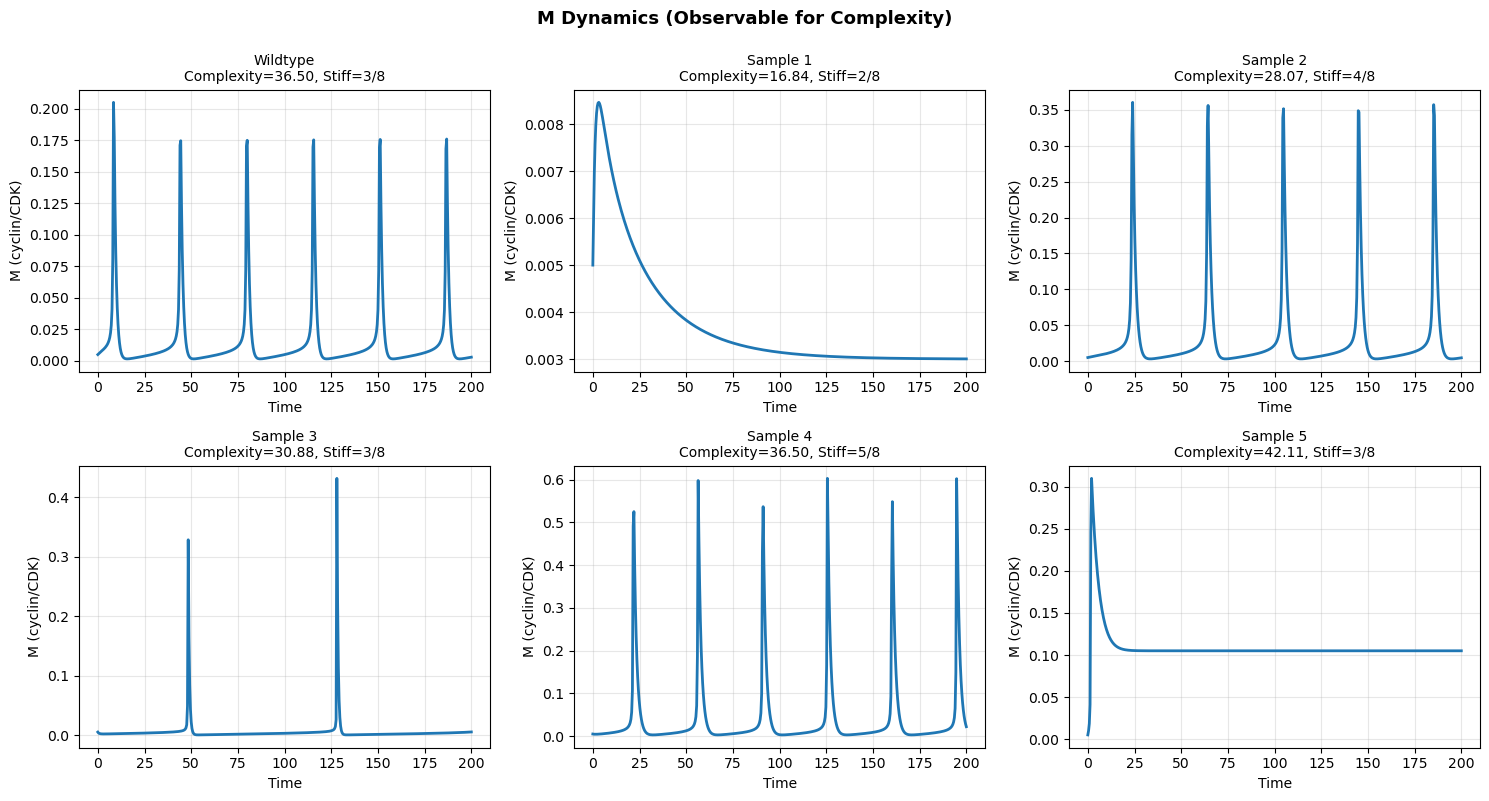

In [ ]:
# === VISUALIZATION: M TRAJECTORIES (COMPLEXITY OBSERVABLE) ===

if len(results) == 0:
    print("No valid results to plot.")
else:
    # Plot M trajectories for first 6 samples (including wildtype if present)
    n_traj = min(6, len(results))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx in range(n_traj):
        entry = results[idx]
        p_sample = entry['params']
        
        # Simulate
        t, states = simulate_for_complexity(p_sample, y0, (0, SIM_TIME), SIM_POINTS)
        
        if t is not None and states is not None:
            M = states[3, :]  # M is the 4th state (index 3)
            
            ax = axes[idx]
            ax.plot(t, M, linewidth=2, color='C0')
            ax.set_xlabel('Time', fontsize=10)
            ax.set_ylabel('M (cyclin/CDK)', fontsize=10)
            ax.set_title(f"{entry['label']}\nComplexity={entry['complexity']:.2f}, "
                        f"Stiff={entry['stiff_count']}/{P}",
                        fontsize=10)
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(n_traj, 6):
        axes[j].axis('off')
    
    plt.suptitle('M Dynamics (Observable for Complexity)', 
                 y=0.995, fontsize=13, weight='bold')
    plt.tight_layout()
    plt.show()

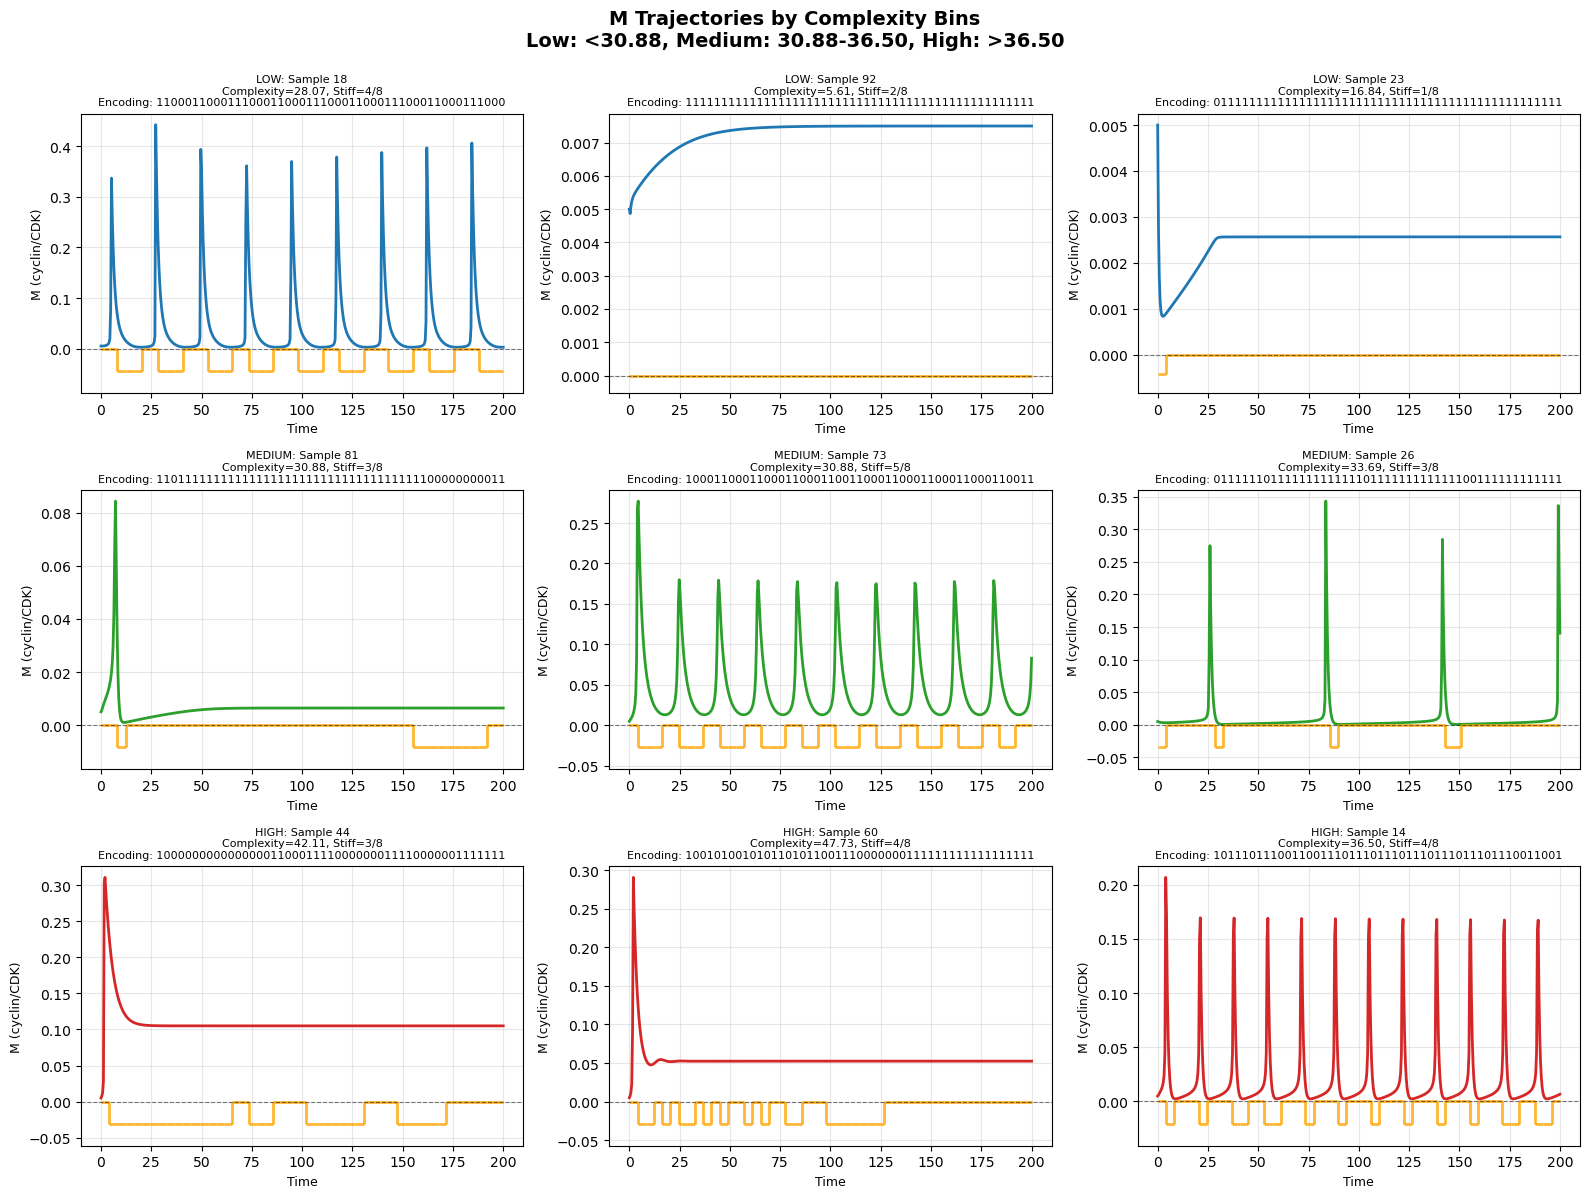


Complexity bin thresholds:
  Low: < 30.88
  Medium: 30.88 - 36.50
  High: > 36.50


In [ ]:
# === VISUALIZATION: LOW/MEDIUM/HIGH COMPLEXITY TRAJECTORIES ===

if len(results) < 9:
    print("Not enough samples for low/medium/high complexity analysis (need at least 9).")
else:
    complexities = np.array([r['complexity'] for r in results])
    
    # Define complexity bins: low (bottom 33%), medium (middle 33%), high (top 33%)
    c_low_threshold = np.percentile(complexities, 33)
    c_high_threshold = np.percentile(complexities, 67)
    
    # Find samples in each bin
    low_indices = np.where(complexities < c_low_threshold)[0]
    mid_indices = np.where((complexities >= c_low_threshold) & (complexities < c_high_threshold))[0]
    high_indices = np.where(complexities >= c_high_threshold)[0]
    
    # Select 3 random samples from each bin
    n_per_bin = 3
    selected_low = np.random.choice(low_indices, min(n_per_bin, len(low_indices)), replace=False)
    selected_mid = np.random.choice(mid_indices, min(n_per_bin, len(mid_indices)), replace=False)
    selected_high = np.random.choice(high_indices, min(n_per_bin, len(high_indices)), replace=False)
    
    # Create 3x3 plot
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    
    # Plot low complexity (row 0)
    for col, idx in enumerate(selected_low):
        entry = results[idx]
        p_sample = entry['params']
        
        t, states = simulate_for_complexity(p_sample, y0, (0, SIM_TIME), SIM_POINTS)
        
        if t is not None and states is not None:
            M = states[3, :]  # M is the 4th state (index 3)
            
            # Compute up-down encoding
            coarse_time, coarse_signal = coarse_grain_direct(t, M, COARSE_BINS)
            encoding = up_down_encoding(coarse_time, coarse_signal)
            
            # Determine y-axis range for encoding visualization
            M_range = M.max() - M.min()
            encoding_level = -0.1 * M_range  # 10% below zero
            y_min = -0.2 * M_range  # extend y-axis to 20% of positive range
            
            ax = axes[0, col]
            ax.plot(t, M, linewidth=2, color='C0', label='M dynamics')
            
            # Plot encoding as step function (flipped: 0->negative, 1->zero)
            n_bins = len(encoding)
            dt_per_bin = SIM_TIME / n_bins
            for i, bit in enumerate(encoding):
                t_start = i * dt_per_bin
                t_end = (i + 1) * dt_per_bin
                level = 0 if bit == '1' else encoding_level
                ax.hlines(level, t_start, t_end, colors='orange', linewidth=2, alpha=0.8)
                if i < n_bins - 1:
                    next_level = 0 if encoding[i+1] == '1' else encoding_level
                    ax.vlines(t_end, level, next_level, colors='orange', linewidth=2, alpha=0.8)
            
            ax.set_ylim([y_min, M.max() * 1.05])
            ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
            ax.set_title(f"LOW: {entry['label']}\nComplexity={entry['complexity']:.2f}, "
                        f"Stiff={entry['stiff_count']}/{P}\nEncoding: {encoding}",
                        fontsize=8)
            ax.set_xlabel('Time', fontsize=9)
            ax.set_ylabel('M (cyclin/CDK)', fontsize=9)
            ax.grid(True, alpha=0.3)
    
    # Plot medium complexity (row 1)
    for col, idx in enumerate(selected_mid):
        entry = results[idx]
        p_sample = entry['params']
        
        t, states = simulate_for_complexity(p_sample, y0, (0, SIM_TIME), SIM_POINTS)
        
        if t is not None and states is not None:
            M = states[3, :]
            
            # Compute up-down encoding
            coarse_time, coarse_signal = coarse_grain_direct(t, M, COARSE_BINS)
            encoding = up_down_encoding(coarse_time, coarse_signal)
            
            # Determine y-axis range
            M_range = M.max() - M.min()
            encoding_level = -0.1 * M_range
            y_min = -0.2 * M_range
            
            ax = axes[1, col]
            ax.plot(t, M, linewidth=2, color='C2', label='M dynamics')
            
            # Plot encoding as step function (flipped: 0->negative, 1->zero)
            n_bins = len(encoding)
            dt_per_bin = SIM_TIME / n_bins
            for i, bit in enumerate(encoding):
                t_start = i * dt_per_bin
                t_end = (i + 1) * dt_per_bin
                level = 0 if bit == '1' else encoding_level
                ax.hlines(level, t_start, t_end, colors='orange', linewidth=2, alpha=0.8)
                if i < n_bins - 1:
                    next_level = 0 if encoding[i+1] == '1' else encoding_level
                    ax.vlines(t_end, level, next_level, colors='orange', linewidth=2, alpha=0.8)
            
            ax.set_ylim([y_min, M.max() * 1.05])
            ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
            ax.set_title(f"MEDIUM: {entry['label']}\nComplexity={entry['complexity']:.2f}, "
                        f"Stiff={entry['stiff_count']}/{P}\nEncoding: {encoding}",
                        fontsize=8)
            ax.set_xlabel('Time', fontsize=9)
            ax.set_ylabel('M (cyclin/CDK)', fontsize=9)
            ax.grid(True, alpha=0.3)
    
    # Plot high complexity (row 2)
    for col, idx in enumerate(selected_high):
        entry = results[idx]
        p_sample = entry['params']
        
        t, states = simulate_for_complexity(p_sample, y0, (0, SIM_TIME), SIM_POINTS)
        
        if t is not None and states is not None:
            M = states[3, :]
            
            # Compute up-down encoding
            coarse_time, coarse_signal = coarse_grain_direct(t, M, COARSE_BINS)
            encoding = up_down_encoding(coarse_time, coarse_signal)
            
            # Determine y-axis range
            M_range = M.max() - M.min()
            encoding_level = -0.1 * M_range
            y_min = -0.2 * M_range
            
            ax = axes[2, col]
            ax.plot(t, M, linewidth=2, color='C3', label='M dynamics')
            
            # Plot encoding as step function (flipped: 0->negative, 1->zero)
            n_bins = len(encoding)
            dt_per_bin = SIM_TIME / n_bins
            for i, bit in enumerate(encoding):
                t_start = i * dt_per_bin
                t_end = (i + 1) * dt_per_bin
                level = 0 if bit == '1' else encoding_level
                ax.hlines(level, t_start, t_end, colors='orange', linewidth=2, alpha=0.8)
                if i < n_bins - 1:
                    next_level = 0 if encoding[i+1] == '1' else encoding_level
                    ax.vlines(t_end, level, next_level, colors='orange', linewidth=2, alpha=0.8)
            
            ax.set_ylim([y_min, M.max() * 1.05])
            ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
            ax.set_title(f"HIGH: {entry['label']}\nComplexity={entry['complexity']:.2f}, "
                        f"Stiff={entry['stiff_count']}/{P}\nEncoding: {encoding}",
                        fontsize=8)
            ax.set_xlabel('Time', fontsize=9)
            ax.set_ylabel('M (cyclin/CDK)', fontsize=9)
            ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'M Trajectories by Complexity Bins\n'
                 f'Low: <{c_low_threshold:.2f}, Medium: {c_low_threshold:.2f}-{c_high_threshold:.2f}, '
                 f'High: >{c_high_threshold:.2f}',
                 y=0.995, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nComplexity bin thresholds:")
    print(f"  Low: < {c_low_threshold:.2f}")
    print(f"  Medium: {c_low_threshold:.2f} - {c_high_threshold:.2f}")
    print(f"  High: > {c_high_threshold:.2f}")

In [ ]:
# === SAVE RESULTS (OPTIONAL) ===

# Uncomment to save results to numpy file
# save_data = {
#     'results': results,
#     'config': {
#         'N_SAMPLES': N_SAMPLES,
#         'SIM_TIME': SIM_TIME,
#         'COARSE_BINS': COARSE_BINS,
#         'STIFF_THRESHOLD': STIFF_THRESHOLD,
#         'MULTIPLIERS': MULTIPLIERS,
#         'param_names': param_names
#     },
#     'p_default': p_default
# }
# np.save('tyson_sloppy_complexity_results.npy', save_data, allow_pickle=True)
# print("Results saved to tyson_sloppy_complexity_results.npy")

print("\n" + "="*70)
print("TysonSloppyComplexity analysis complete!")
print("="*70)


TysonSloppyComplexity analysis complete!



PERFORMANCE BOTTLENECK ANALYSIS

Complexity computation (simulation + CLZ):
  Mean: 0.154s
  Std:  0.124s
  Min:  0.026s
  Max:  0.475s
  Total: 15.4s (35.8%)

Hessian computation (sensitivity ODEs):
  Mean: 0.275s
  Std:  0.194s
  Min:  0.063s
  Max:  1.209s
  Total: 27.5s (64.2%)

Hessian / Complexity ratio: 1.79x
  → Balanced: Both steps take similar time


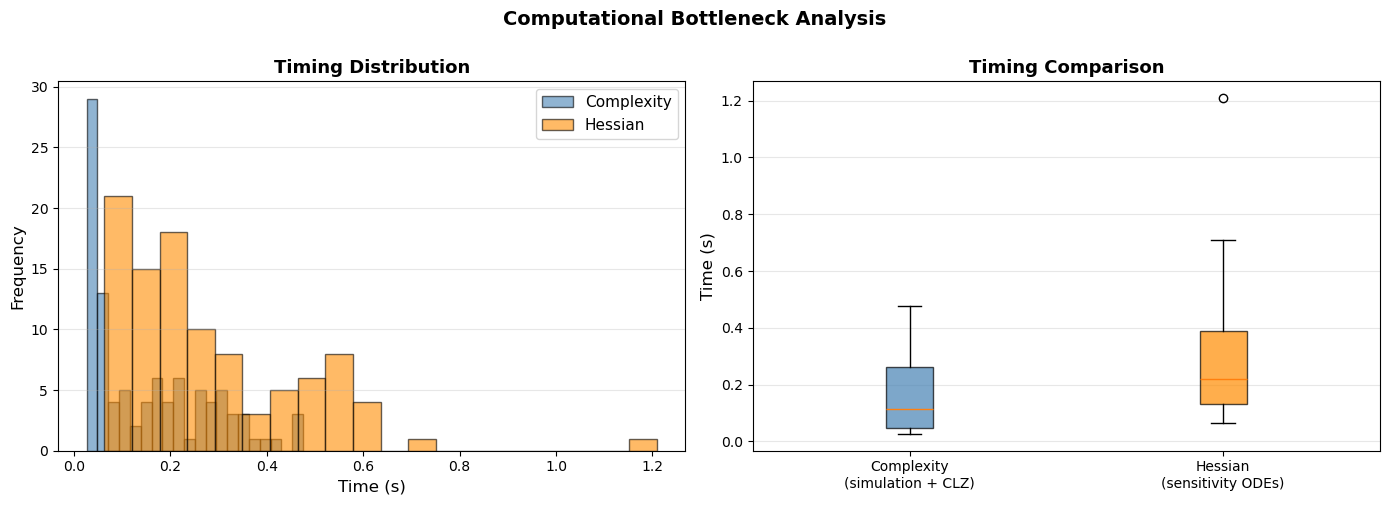

In [80]:
# === PERFORMANCE ANALYSIS: BOTTLENECK DETECTION ===

if len(timing_complexity) > 0 and len(timing_hessian) > 0:
    timing_complexity = np.array(timing_complexity)
    timing_hessian = np.array(timing_hessian)
    
    print("\n" + "="*70)
    print("PERFORMANCE BOTTLENECK ANALYSIS")
    print("="*70)
    
    # Statistics
    print(f"\nComplexity computation (simulation + CLZ):")
    print(f"  Mean: {timing_complexity.mean():.3f}s")
    print(f"  Std:  {timing_complexity.std():.3f}s")
    print(f"  Min:  {timing_complexity.min():.3f}s")
    print(f"  Max:  {timing_complexity.max():.3f}s")
    print(f"  Total: {timing_complexity.sum():.1f}s ({100*timing_complexity.sum()/(timing_complexity.sum()+timing_hessian.sum()):.1f}%)")
    
    print(f"\nHessian computation (sensitivity ODEs):")
    print(f"  Mean: {timing_hessian.mean():.3f}s")
    print(f"  Std:  {timing_hessian.std():.3f}s")
    print(f"  Min:  {timing_hessian.min():.3f}s")
    print(f"  Max:  {timing_hessian.max():.3f}s")
    print(f"  Total: {timing_hessian.sum():.1f}s ({100*timing_hessian.sum()/(timing_complexity.sum()+timing_hessian.sum()):.1f}%)")
    
    ratio = timing_hessian.mean() / timing_complexity.mean()
    print(f"\nHessian / Complexity ratio: {ratio:.2f}x")
    
    if ratio > 2:
        print("  → BOTTLENECK: Hessian computation is the limiting factor")
    elif ratio < 0.5:
        print("  → BOTTLENECK: Complexity simulation is the limiting factor")
    else:
        print("  → Balanced: Both steps take similar time")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram comparison
    ax = axes[0]
    ax.hist(timing_complexity, bins=20, alpha=0.6, label='Complexity', color='steelblue', edgecolor='black')
    ax.hist(timing_hessian, bins=20, alpha=0.6, label='Hessian', color='darkorange', edgecolor='black')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Timing Distribution', fontsize=13, weight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Box plot comparison
    ax = axes[1]
    bp = ax.boxplot([timing_complexity, timing_hessian], 
                     labels=['Complexity\n(simulation + CLZ)', 'Hessian\n(sensitivity ODEs)'],
                     patch_artist=True, showfliers=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('darkorange')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax.set_ylabel('Time (s)', fontsize=12)
    ax.set_title('Timing Comparison', fontsize=13, weight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Computational Bottleneck Analysis', y=1.00, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("\nNo timing data available for bottleneck analysis.")